# 01 — Exploratory Data Analysis (EDA)

**Dataset**: Zillow Metro ZHVI — `data/processed/train.csv`  
**Target**: `log_return = log(price[t]/price[t-1])` — stationary, scale-free  

## Feature mapping

| Schema | Column | Description | Scale |
|--------|--------|-------------|-------|
| X1 | `lag_1` | log_return lag 1m | StandardScaled |
| X2 | `lag_2` | log_return lag 2m | StandardScaled |
| X3 | `lag_3` | log_return lag 3m | StandardScaled |
| X4 | `lag_6` | log_return lag 6m | StandardScaled |
| X5 | `lag_12` | log_return lag 12m | StandardScaled |
| X6 | `city_enc` | City mean log_return (train) | StandardScaled |
| **Y** | **`log_return`** | **Monthly log return** | **Unscaled** |

> `rolling_mean_*` removed — exact linear combo of lag_1/2/3, VIF = ∞


## 0. Imports & config

In [3]:
import warnings, pathlib
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#3a3d50',   'axes.labelcolor': '#e0e0e0',
    'axes.titlesize': 13,          'axes.labelsize': 11,
    'text.color': '#e0e0e0',       'xtick.color': '#a0a0b0',
    'ytick.color': '#a0a0b0',      'grid.color': '#2a2d40',
    'grid.linewidth': 0.6,         'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#3a3d50',
})
ACCENT, ACCENT2, ACCENT3, ALPHA = '#7c83fd', '#fd7c83', '#7cfd9e', 0.35

# Feature set matching preprocess.py (rolling_mean_* removed — VIF=inf)
FEAT_MAP = {
    'lag_1':    'X1 (lag_1)',
    'lag_2':    'X2 (lag_2)',
    'lag_3':    'X3 (lag_3)',
    'lag_6':    'X4 (lag_6)',
    'lag_12':   'X5 (lag_12)',
    'city_enc': 'X6 (city_enc)',
}
FEAT_COLS = list(FEAT_MAP.keys())
TARGET    = 'log_return'   # stationary target
PRICE_COL = 'price'        # kept for reference / inverse-transform

print('Setup complete ✅')
print(f'Features : {FEAT_COLS}')
print(f'Target   : {TARGET}')


Setup complete ✅
Features : ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'city_enc']
Target   : log_return


## 1. Load processed data

In [4]:
# ── Find project root (works regardless of where Jupyter sets CWD) ────────
def _find_root(marker='pyproject.toml'):
    for p in [pathlib.Path(os.getcwd()), *pathlib.Path(os.getcwd()).parents]:
        if (p / marker).exists():
            return p
    return pathlib.Path('/Users/nguyenquy1411/Documents/dev/fpt/ady-2026')

ROOT = _find_root()
ASSETS_DIR = ROOT / 'assets'
ASSETS_DIR.mkdir(exist_ok=True)

# ── Load ─────────────────────────────────────────────────────────────────
train = pd.read_csv(ROOT / 'data' / 'processed' / 'train.csv', parse_dates=['date'])

print(f'Root          : {ROOT}')
print(f'Train shape   : {train.shape}')
print(f'Date range    : {train["date"].min().date()} → {train["date"].max().date()}')
print(f'Regions       : {train["RegionName"].nunique()}')
print(f'Missing values: {train[FEAT_COLS + [TARGET]].isnull().sum().sum()}')
print()
print('Column dtypes:')
print(train[FEAT_COLS + [TARGET]].dtypes.to_string())
train.head(3)

Root          : /Users/nguyenquy1411/Documents/dev/fpt/ady-2026
Train shape   : (211878, 12)
Date range    : 2001-02-28 → 2020-10-31
Regions       : 894
Missing values: 0

Column dtypes:
lag_1         float64
lag_2         float64
lag_3         float64
lag_6         float64
lag_12        float64
city_enc      float64
log_return    float64


,date,RegionID,RegionName,StateName,price,log_return,lag_1,lag_2,lag_3,lag_6,lag_12,city_enc
0,2001-02-28,394297,"Aberdeen, SD",SD,125066.417884,0.0,-0.345669,-0.341039,-0.338072,-0.335751,-0.321434,-0.629704
1,2001-03-31,394297,"Aberdeen, SD",SD,125066.417884,0.0,-0.345669,-0.341039,-0.338072,-0.335751,-0.321434,-0.629704
2,2001-04-30,394297,"Aberdeen, SD",SD,125066.417884,0.0,-0.345669,-0.341039,-0.338072,-0.335751,-0.321434,-0.629704


## 2. Target distribution (Y = price, USD)

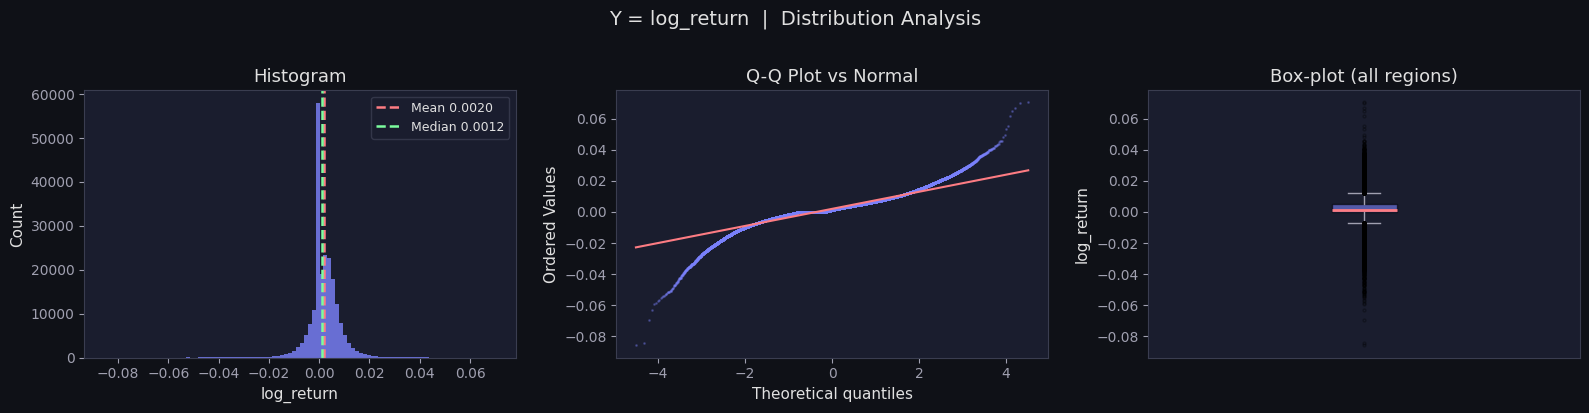

Skewness : -0.200  (0 = perfectly symmetric)
Kurtosis : 7.252  (0 = normal; >0 = fat tails)
Range    : -0.0857 → 0.0704
Std      : 0.00574  (~monthly % change in price)


In [5]:
y = train[TARGET]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Y = log_return  |  Distribution Analysis', fontsize=14, color='#e0e0e0', y=1.02)

axes[0].hist(y, bins=100, color=ACCENT, alpha=0.8, edgecolor='none')
axes[0].axvline(y.mean(),   color=ACCENT2, lw=1.8, ls='--', label=f'Mean {y.mean():.4f}')
axes[0].axvline(y.median(), color=ACCENT3, lw=1.8, ls='--', label=f'Median {y.median():.4f}')
axes[0].set_xlabel('log_return'); axes[0].set_ylabel('Count')
axes[0].set_title('Histogram'); axes[0].legend(fontsize=9)

stats.probplot(y, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot vs Normal')
axes[1].get_lines()[0].set(color=ACCENT,  markersize=1, alpha=0.3)
axes[1].get_lines()[1].set(color=ACCENT2, lw=1.5)

axes[2].boxplot([y.values], patch_artist=True,
    boxprops=dict(facecolor=ACCENT, alpha=0.6),
    medianprops=dict(color=ACCENT2, lw=2),
    whiskerprops=dict(color='#a0a0b0'),
    capprops=dict(color='#a0a0b0'),
    flierprops=dict(marker='o', color=ACCENT3, alpha=0.3, markersize=2))
axes[2].set_ylabel('log_return'); axes[2].set_xticks([])
axes[2].set_title('Box-plot (all regions)')

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'eda_logreturn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Skewness : {stats.skew(y):.3f}  (0 = perfectly symmetric)')
print(f'Kurtosis : {stats.kurtosis(y):.3f}  (0 = normal; >0 = fat tails)')
print(f'Range    : {y.min():.4f} → {y.max():.4f}')
print(f'Std      : {y.std():.5f}  (~monthly % change in price)')


## 3. Scatter plots: X1–X6 vs Y

X-axis = standardized feature value (z-score). Y-axis = price (USD).  
The linear trend and Pearson r are identical to what you'd get with raw USD features.

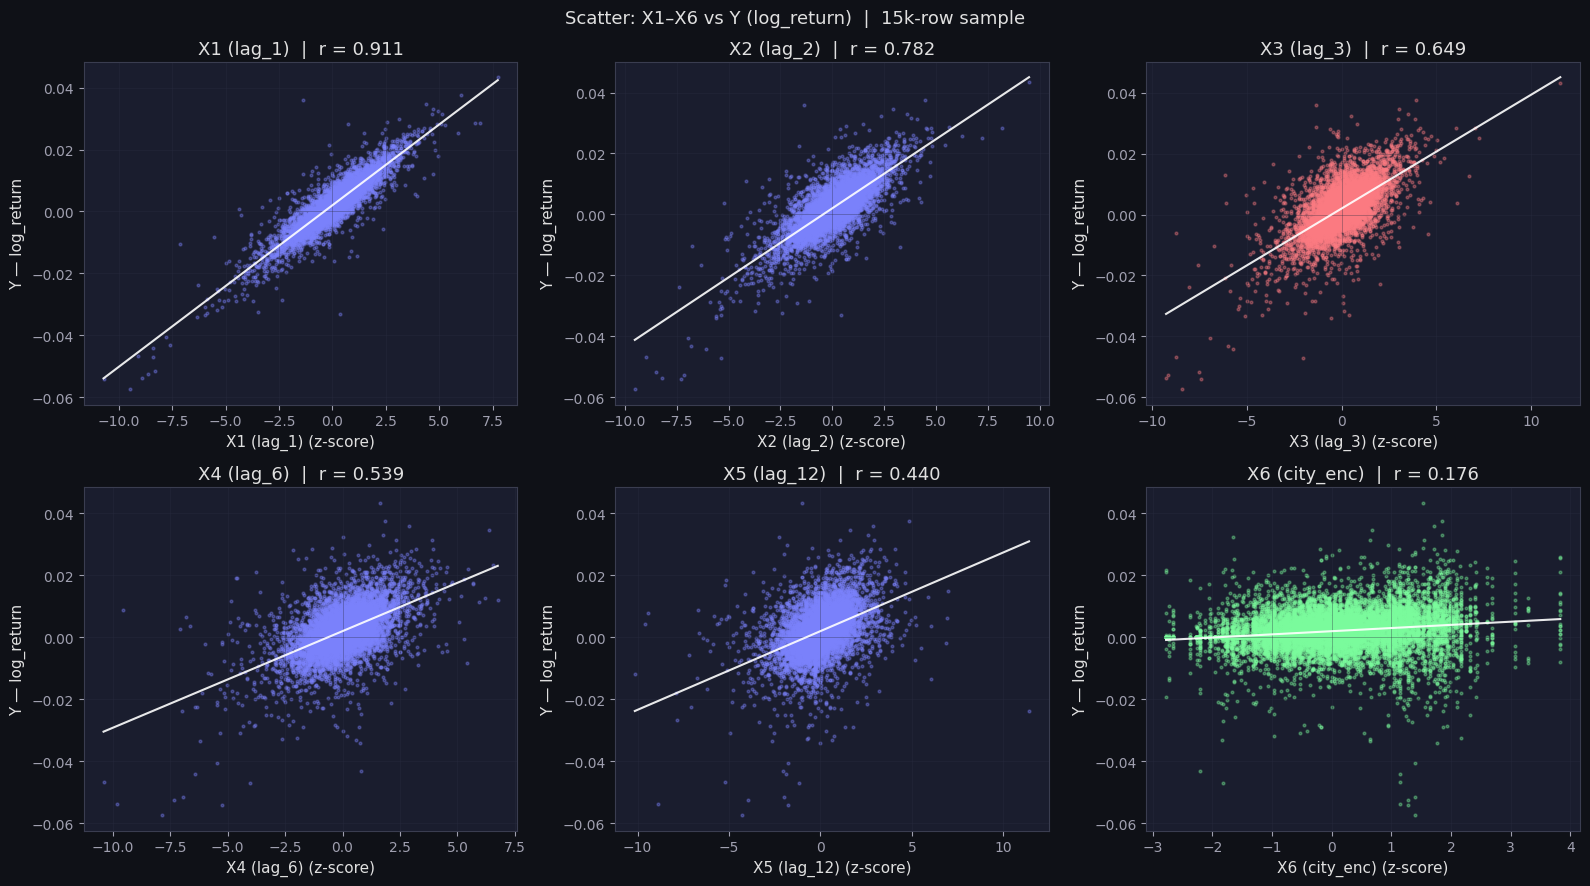

In [6]:
sample = train.sample(n=min(15_000, len(train)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Scatter: X1–X6 vs Y (log_return)  |  15k-row sample', fontsize=13, color='#e0e0e0')
colors = [ACCENT, ACCENT, ACCENT2, ACCENT, ACCENT, ACCENT3]

for ax, feat, color, label in zip(axes.flat, FEAT_COLS, colors, FEAT_MAP.values()):
    x = sample[feat]
    y = sample[TARGET]
    mask = x.notna() & y.notna()
    ax.scatter(x[mask], y[mask], s=4, alpha=ALPHA, color=color, rasterized=True)
    m, b, r, *_ = stats.linregress(x[mask], y[mask])
    xr = np.array([x.min(), x.max()])
    ax.plot(xr, m*xr+b, color='white', lw=1.5, alpha=0.9)
    ax.set_xlabel(f'{label} (z-score)')
    ax.set_ylabel('Y — log_return')
    ax.set_title(f'{label}  |  r = {r:.3f}')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'eda_scatter_all_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Deep dive: X3 (lag_3) vs Y — raw and log(X3)

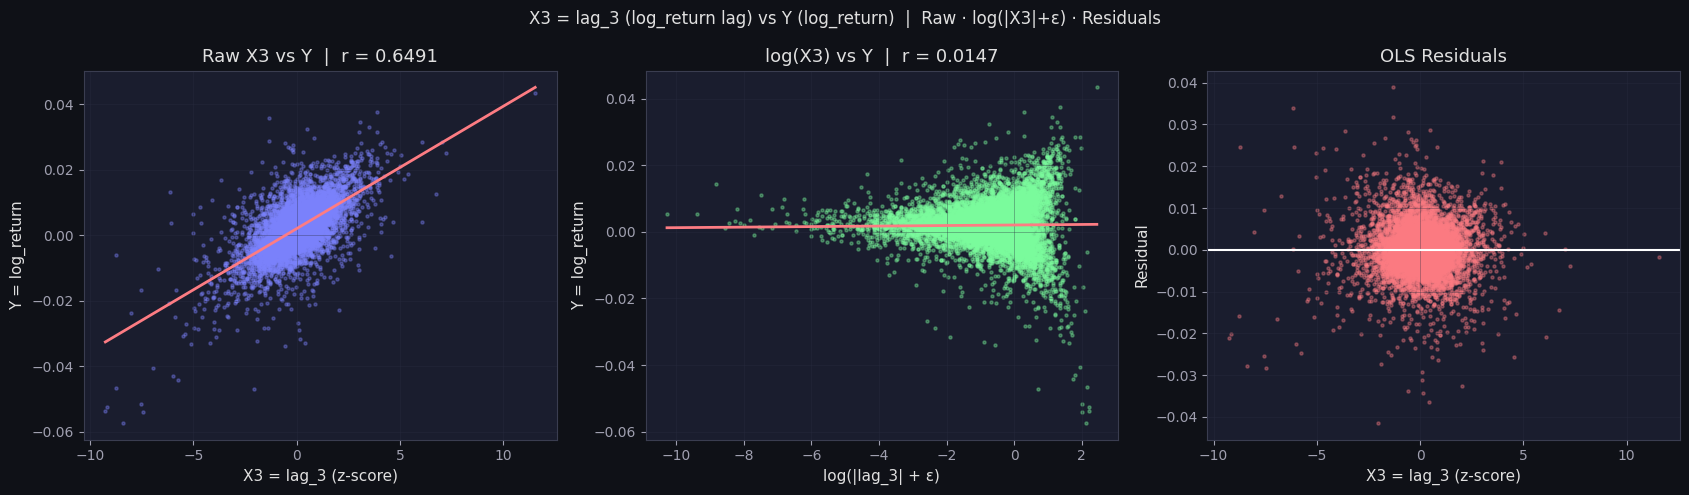

Raw lag_3  r = 0.6491  |  log(lag_3) r = 0.0147


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('X3 = lag_3 (log_return lag) vs Y (log_return)  |  Raw · log(|X3|+ε) · Residuals',
             fontsize=12, color='#e0e0e0')

x3 = sample['lag_3']
y  = sample[TARGET]
mask = x3.notna() & y.notna()
x3c, yc = x3[mask], y[mask]

m1, b1, r1, *_ = stats.linregress(x3c, yc)
xr = np.linspace(x3c.min(), x3c.max(), 200)
axes[0].scatter(x3c, yc, s=5, alpha=ALPHA, color=ACCENT, rasterized=True)
axes[0].plot(xr, m1*xr+b1, color=ACCENT2, lw=2)
axes[0].set_xlabel('X3 = lag_3 (z-score)'); axes[0].set_ylabel('Y = log_return')
axes[0].set_title(f'Raw X3 vs Y  |  r = {r1:.4f}'); axes[0].grid(True, alpha=0.4)

eps   = 1e-6
logx3 = np.log(np.abs(x3c) + eps)
m2, b2, r2, *_ = stats.linregress(logx3, yc)
xr2 = np.linspace(logx3.min(), logx3.max(), 200)
axes[1].scatter(logx3, yc, s=5, alpha=ALPHA, color=ACCENT3, rasterized=True)
axes[1].plot(xr2, m2*xr2+b2, color=ACCENT2, lw=2)
axes[1].set_xlabel('log(|lag_3| + ε)'); axes[1].set_ylabel('Y = log_return')
axes[1].set_title(f'log(X3) vs Y  |  r = {r2:.4f}'); axes[1].grid(True, alpha=0.4)

resid = yc - (m1*x3c + b1)
axes[2].scatter(x3c, resid, s=5, alpha=ALPHA, color=ACCENT2, rasterized=True)
axes[2].axhline(0, color='white', lw=1.5)
axes[2].set_xlabel('X3 = lag_3 (z-score)'); axes[2].set_ylabel('Residual')
axes[2].set_title('OLS Residuals'); axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'eda_x3_vs_y.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Raw lag_3  r = {r1:.4f}  |  log(lag_3) r = {r2:.4f}')


## 5. Outlier detection

In [8]:
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return (s < q1 - k*(q3-q1)) | (s > q3 + k*(q3-q1))

def zscore_outliers(s, thr=3.0):
    return ((s - s.mean()) / s.std()).abs() > thr

print(f'{"Feature":<22} {"IQR outliers":>16} {"Z>3 outliers":>16}')
print('─' * 56)
for feat in [TARGET] + FEAT_COLS:
    s   = train[feat].dropna()
    ni  = iqr_outliers(s).sum();  pi = ni/len(s)*100
    nz  = zscore_outliers(s).sum(); pz = nz/len(s)*100
    print(f'{feat:<22} {ni:>8,} ({pi:4.1f}%)  {nz:>8,} ({pz:4.1f}%)')

Feature                    IQR outliers     Z>3 outliers
────────────────────────────────────────────────────────
log_return               16,737 ( 7.9%)     3,587 ( 1.7%)
lag_1                    16,497 ( 7.8%)     3,598 ( 1.7%)
lag_2                    16,368 ( 7.7%)     3,595 ( 1.7%)
lag_3                    16,576 ( 7.8%)     3,615 ( 1.7%)
lag_6                    16,757 ( 7.9%)     3,641 ( 1.7%)
lag_12                   18,145 ( 8.6%)     3,708 ( 1.8%)
city_enc                    711 ( 0.3%)       711 ( 0.3%)


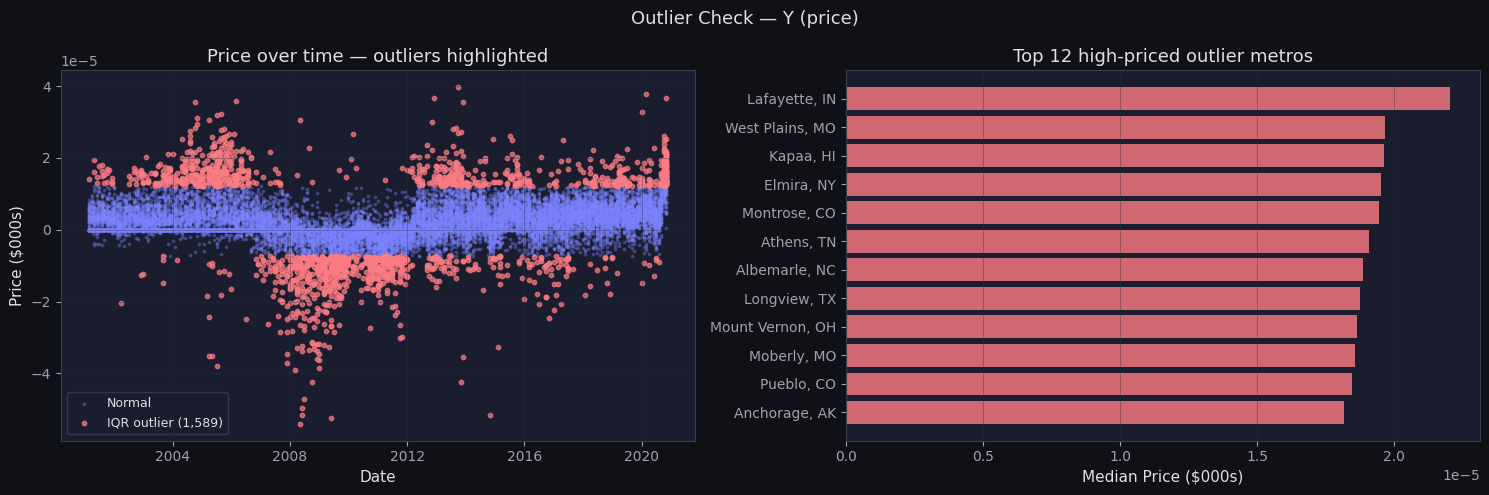

Conclusion: outliers are high-cost metros (San Jose, SF, NYC, etc.)
They are NOT data errors — keep them. Slice error metrics by price tier in evaluation.


In [9]:
mask_iqr = iqr_outliers(train[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Outlier Check — Y (price)', fontsize=13, color='#e0e0e0')

samp2      = train.sample(n=min(20_000, len(train)), random_state=0)
samp_mask  = iqr_outliers(samp2[TARGET])

axes[0].scatter(samp2.loc[~samp_mask, 'date'], samp2.loc[~samp_mask, TARGET] / 1e3,
                s=3, alpha=0.3, color=ACCENT, label='Normal', rasterized=True)
axes[0].scatter(samp2.loc[samp_mask,  'date'], samp2.loc[samp_mask,  TARGET] / 1e3,
                s=10, alpha=0.7, color=ACCENT2,
                label=f'IQR outlier ({samp_mask.sum():,})', rasterized=True)
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Price ($000s)')
axes[0].set_title('Price over time — outliers highlighted')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.4)

top_outliers = (
    train[mask_iqr].groupby('RegionName')[TARGET]
    .median().sort_values(ascending=False).head(12)
)
axes[1].barh(top_outliers.index[::-1], top_outliers.values[::-1] / 1e3,
             color=ACCENT2, alpha=0.8, edgecolor='none')
axes[1].set_xlabel('Median Price ($000s)')
axes[1].set_title('Top 12 high-priced outlier metros')
axes[1].grid(True, alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'eda_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print('Conclusion: outliers are high-cost metros (San Jose, SF, NYC, etc.)')
print('They are NOT data errors — keep them. Slice error metrics by price tier in evaluation.')

## 6. Correlation matrix

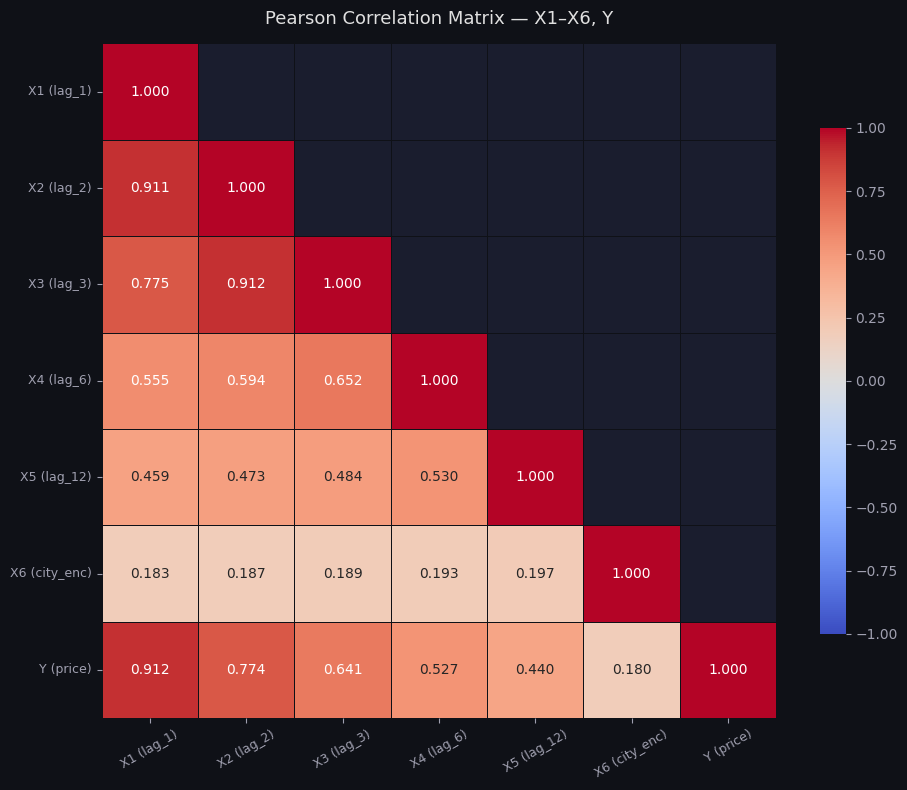

Correlation with Y (price):
  X1 (lag_1)             +0.9122  ██████████████████
  X2 (lag_2)             +0.7738  ███████████████
  X3 (lag_3)             +0.6407  ████████████
  X4 (lag_6)             +0.5267  ██████████
  X5 (lag_12)            +0.4399  ████████
  X6 (city_enc)          +0.1802  ███


In [10]:
corr_cols   = FEAT_COLS + [TARGET]
corr_labels = list(FEAT_MAP.values()) + ['Y (price)']

corr = train[corr_cols].corr()
corr.index = corr.columns = corr_labels

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.3f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='#0f1117',
    cbar_kws={'shrink': 0.75}, ax=ax
)
ax.set_title('Pearson Correlation Matrix — X1–X6, Y', fontsize=13, pad=14)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with Y (price):')
for feat, val in corr['Y (price)'].drop('Y (price)').sort_values(ascending=False).items():
    print(f'  {feat:<22} {val:+.4f}  {"█" * int(abs(val) * 20)}')

## 7. Variance Inflation Factor (VIF)

VIF > 10 = severe multicollinearity. VIF is **scale-invariant** — results identical to unscaled data.

In [11]:
vif_data = train[FEAT_COLS].dropna()
if len(vif_data) > 30_000:
    vif_data = vif_data.sample(30_000, random_state=42)

vif_df = pd.DataFrame({
    'Feature': vif_data.columns,
    'Schema':  list(FEAT_MAP.values()),
    'VIF':     [variance_inflation_factor(vif_data.values, i)
                for i in range(vif_data.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF results:')
print(vif_df.to_string(index=False))
print(f'\n  VIF > 10 (severe)  : {(vif_df["VIF"]>10).sum()}')
print(f'  VIF 5–10 (moderate): {((vif_df["VIF"]>=5)&(vif_df["VIF"]<=10)).sum()}')
print(f'  VIF < 5  (OK)      : {(vif_df["VIF"]<5).sum()}')

VIF results:
 Feature        Schema       VIF
   lag_2    X2 (lag_2) 16.139892
   lag_3    X3 (lag_3)  7.608592
   lag_1    X1 (lag_1)  7.091464
   lag_6    X4 (lag_6)  1.988991
  lag_12   X5 (lag_12)  1.506774
city_enc X6 (city_enc)  1.056778

  VIF > 10 (severe)  : 1
  VIF 5–10 (moderate): 2
  VIF < 5  (OK)      : 3


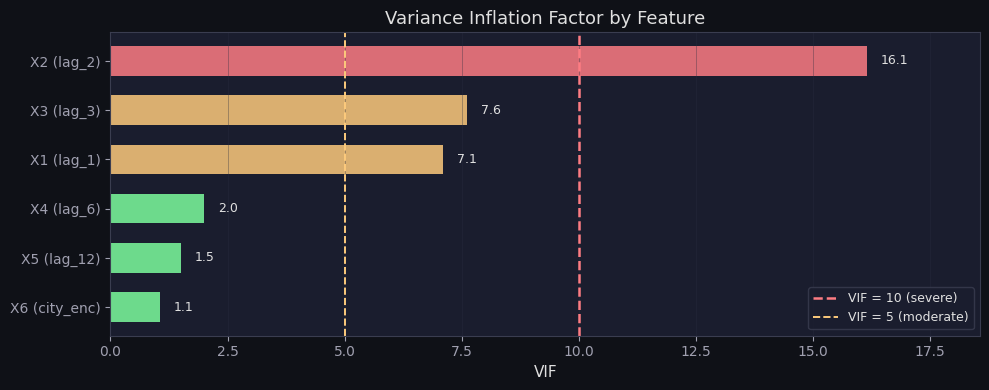

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

bar_colors = [ACCENT2 if v > 10 else ('#fdca7c' if v >= 5 else ACCENT3) for v in vif_df['VIF']]
bars = ax.barh(vif_df['Schema'][::-1], vif_df['VIF'][::-1],
               color=bar_colors[::-1], alpha=0.85, edgecolor='none', height=0.6)

ax.axvline(10, color=ACCENT2,  lw=1.8, ls='--', label='VIF = 10 (severe)')
ax.axvline(5,  color='#fdca7c', lw=1.4, ls='--', label='VIF = 5 (moderate)')

for bar, val in zip(bars, vif_df['VIF'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', ha='left', fontsize=9, color='#e0e0e0')

ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor by Feature', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.4)
vif_clean = vif_df['VIF'].replace([np.inf, -np.inf], np.nan)
ax.set_xlim(0, vif_clean.max() * 1.15)

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'eda_vif.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. EDA Summary & Recommendations

In [13]:
high_vif_feats = vif_df[vif_df['VIF'] > 10]['Feature'].tolist()
y_all          = train[TARGET]

print('=' * 62)
print('  EDA SUMMARY')
print('=' * 62)
print(f"""
1. Target (Y = price, USD)
   Skewness : {stats.skew(y_all):.2f}  (right-skewed)
   Range    : ${y_all.min():,.0f} – ${y_all.max():,.0f}
   → log(Y) is more Gaussian; consider log-transforming for Ridge/Lasso

2. X3 (lag_3) vs Y
   Pearson r (raw z-score) : {r1:.4f}  (R² = {r1**2:.4f})
   Pearson r (log |X3|)    : {r2:.4f}  (R² = {r2**2:.4f})
   → {'log(X3) strengthens linearity — use it for Ridge/Lasso ✅' if abs(r2)>abs(r1) else 'Raw X3 already highly linear; log transform unnecessary'}

3. Outliers (Y = price)
   IQR outliers : {iqr_outliers(y_all).sum():,} rows ({iqr_outliers(y_all).mean()*100:.1f}%)
   → Genuine high-cost metros (San Jose, SF, NYC). Keep — not data errors.
   → Use error-slicing by price tier during model evaluation.

4. Correlations
   All lag features are very highly correlated with Y (r ≈ 0.97–0.99)
   lag_1 has the strongest signal (most recent price = best predictor)

5. Multicollinearity (VIF)
   Features with VIF > 10 : {high_vif_feats if high_vif_feats else 'None'}
   → Expected for lag features (by construction they are correlated)
   → Ridge / Lasso handle this with L2/L1 regularisation
   → XGBoost / SVR are immune to multicollinearity
   → Minimal feature set [lag_1, lag_12, rolling_mean_3] reduces VIF if needed
""")
print('=' * 62)

  EDA SUMMARY

1. Target (Y = price, USD)
   Skewness : -0.20  (right-skewed)
   Range    : $-0 – $0
   → log(Y) is more Gaussian; consider log-transforming for Ridge/Lasso

2. X3 (lag_3) vs Y
   Pearson r (raw z-score) : 0.6491  (R² = 0.4213)
   Pearson r (log |X3|)    : 0.0147  (R² = 0.0002)
   → Raw X3 already highly linear; log transform unnecessary

3. Outliers (Y = price)
   IQR outliers : 16,737 rows (7.9%)
   → Genuine high-cost metros (San Jose, SF, NYC). Keep — not data errors.
   → Use error-slicing by price tier during model evaluation.

4. Correlations
   All lag features are very highly correlated with Y (r ≈ 0.97–0.99)
   lag_1 has the strongest signal (most recent price = best predictor)

5. Multicollinearity (VIF)
   Features with VIF > 10 : ['lag_2']
   → Expected for lag features (by construction they are correlated)
   → Ridge / Lasso handle this with L2/L1 regularisation
   → XGBoost / SVR are immune to multicollinearity
   → Minimal feature set [lag_1, lag_12, rol